# Todo REST API Performance Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
import os

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

output_dir = Path('performance_graphs')
output_dir.mkdir(exist_ok=True)

## 1. Load Performance Data

In [2]:
results_dir = Path('performance-unit-tests/target/performance-results')

todo_df = pd.read_csv(results_dir / 'todo_performance_results.csv')
category_df = pd.read_csv(results_dir / 'category_performance_results.csv')
project_df = pd.read_csv(results_dir / 'project_performance_results.csv')
relationship_df = pd.read_csv(results_dir / 'relationship_performance_results.csv')

todo_df['Entity'] = 'Todo'
category_df['Entity'] = 'Category'
project_df['Entity'] = 'Project'
relationship_df['Entity'] = 'Relationship'

all_data = pd.concat([todo_df, category_df, project_df, relationship_df], ignore_index=True)

print(f"\nTotal records: {len(all_data)}")
print(f"\nColumns: {list(all_data.columns)}")
all_data.head()


Total records: 74

Columns: ['TestName', 'ObjectCount', 'OperationType', 'AverageTimeMs', 'MinTimeMs', 'MaxTimeMs', 'MedianTimeMs', 'TotalTimeMs', 'AverageCpuPercent', 'AverageMemoryMB', 'SampleCount', 'Timestamp', 'Entity']


,TestName,ObjectCount,OperationType,AverageTimeMs,MinTimeMs,MaxTimeMs,MedianTimeMs,TotalTimeMs,AverageCpuPercent,AverageMemoryMB,SampleCount,Timestamp,Entity
0,TodoCreate,10,CREATE,7.123,5.971,10.579,6.748,71.226,9.84,89.27,10,Tue Dec 02 22:04:09 EST 2025,Todo
1,TodoCreate,25,CREATE,6.418,5.699,9.118,6.220,160.438,9.98,89.03,25,Tue Dec 02 22:04:09 EST 2025,Todo
2,TodoCreate,50,CREATE,6.608,5.406,11.651,6.457,330.424,10.02,89.02,50,Tue Dec 02 22:04:09 EST 2025,Todo
3,TodoCreate,100,CREATE,6.450,5.466,9.638,6.388,645.049,9.99,89.02,100,Tue Dec 02 22:04:09 EST 2025,Todo
4,TodoCreate,250,CREATE,6.051,5.186,10.255,5.832,1512.648,10.02,89.29,250,Tue Dec 02 22:04:09 EST 2025,Todo


## 2. Basic Performance Analysis: Average Time vs Object Count

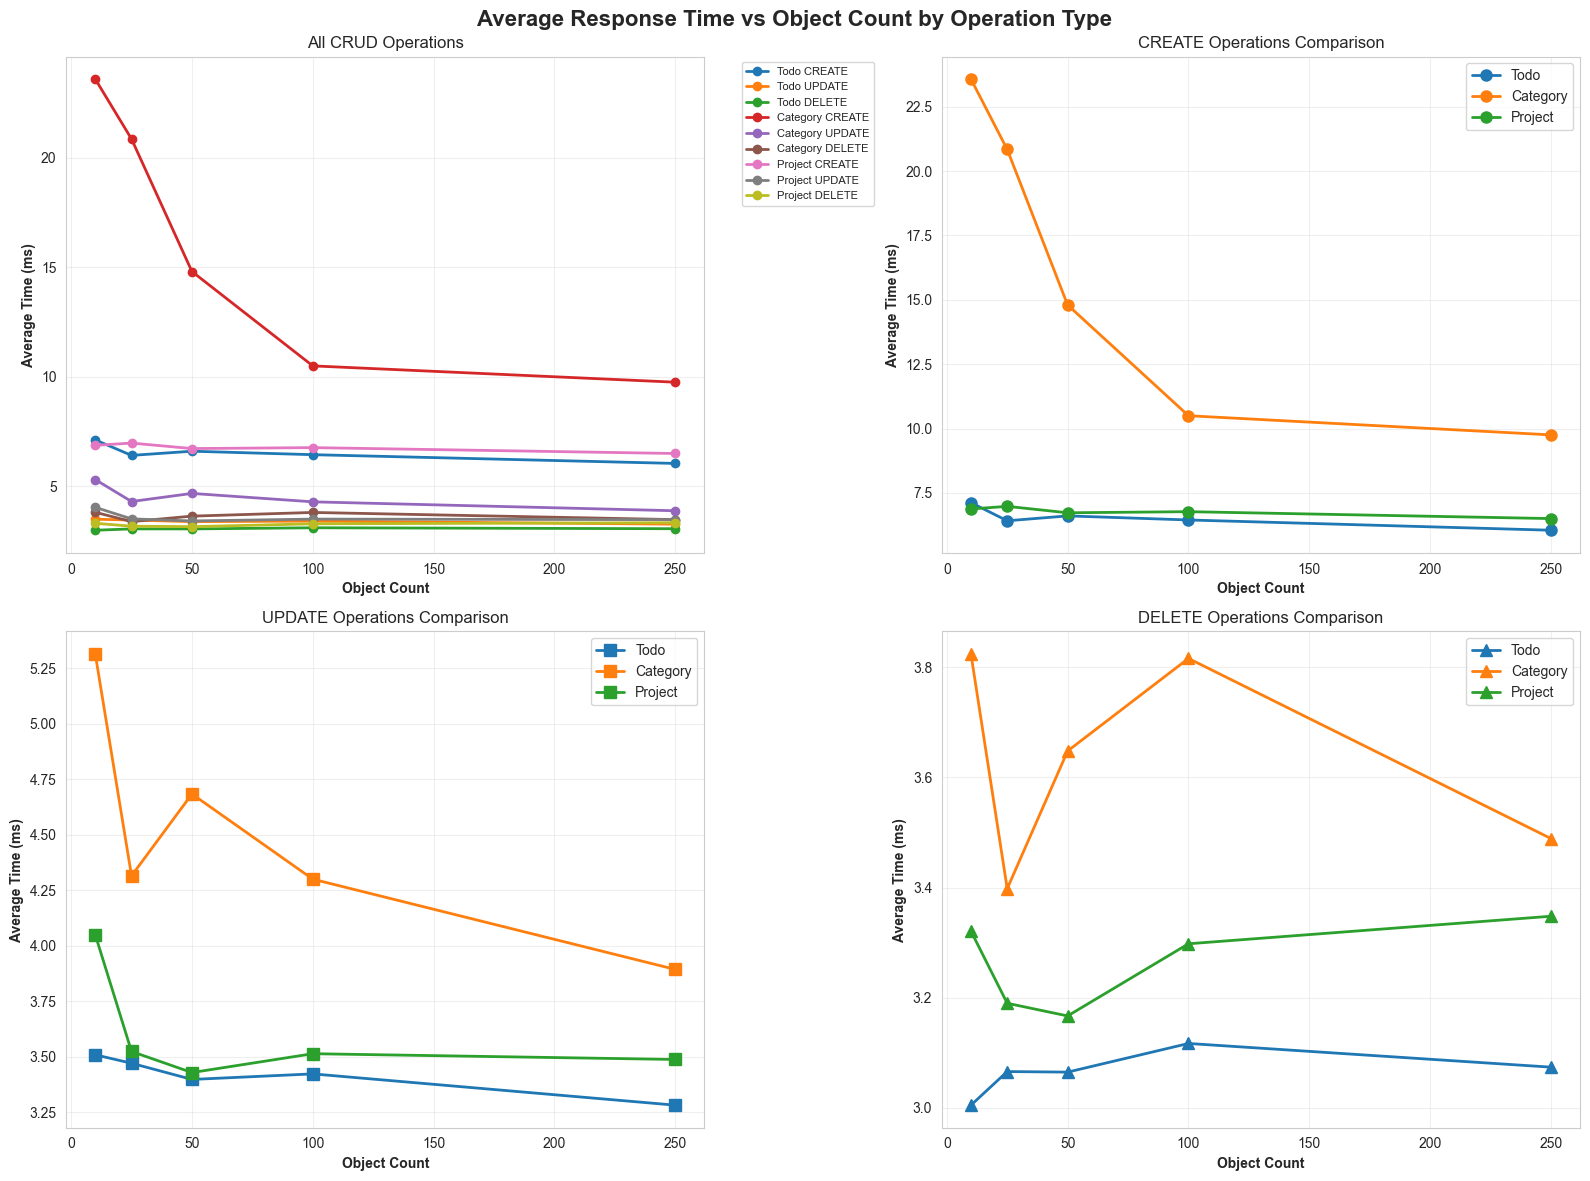

In [3]:
crud_ops = all_data[all_data['OperationType'].isin(['CREATE', 'UPDATE', 'DELETE'])]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Average Response Time vs Object Count by Operation Type', fontsize=16, fontweight='bold')

operations = ['CREATE', 'UPDATE', 'DELETE']
entities = ['Todo', 'Category', 'Project']

# Plot 1: All CRUD operations together
ax = axes[0, 0]
for entity in entities:
    entity_data = crud_ops[crud_ops['Entity'] == entity]
    for op in operations:
        op_data = entity_data[entity_data['OperationType'] == op]
        ax.plot(op_data['ObjectCount'], op_data['AverageTimeMs'], 
                marker='o', label=f'{entity} {op}', linewidth=2)

ax.set_xlabel('Object Count', fontweight='bold')
ax.set_ylabel('Average Time (ms)', fontweight='bold')
ax.set_title('All CRUD Operations')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 2: CREATE operations only
ax = axes[0, 1]
for entity in entities:
    entity_data = crud_ops[(crud_ops['Entity'] == entity) & (crud_ops['OperationType'] == 'CREATE')]
    ax.plot(entity_data['ObjectCount'], entity_data['AverageTimeMs'], 
            marker='o', label=entity, linewidth=2, markersize=8)

ax.set_xlabel('Object Count', fontweight='bold')
ax.set_ylabel('Average Time (ms)', fontweight='bold')
ax.set_title('CREATE Operations Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: UPDATE operations only
ax = axes[1, 0]
for entity in entities:
    entity_data = crud_ops[(crud_ops['Entity'] == entity) & (crud_ops['OperationType'] == 'UPDATE')]
    ax.plot(entity_data['ObjectCount'], entity_data['AverageTimeMs'], 
            marker='s', label=entity, linewidth=2, markersize=8)

ax.set_xlabel('Object Count', fontweight='bold')
ax.set_ylabel('Average Time (ms)', fontweight='bold')
ax.set_title('UPDATE Operations Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: DELETE operations only
ax = axes[1, 1]
for entity in entities:
    entity_data = crud_ops[(crud_ops['Entity'] == entity) & (crud_ops['OperationType'] == 'DELETE')]
    ax.plot(entity_data['ObjectCount'], entity_data['AverageTimeMs'], 
            marker='^', label=entity, linewidth=2, markersize=8)

ax.set_xlabel('Object Count', fontweight='bold')
ax.set_ylabel('Average Time (ms)', fontweight='bold')
ax.set_title('DELETE Operations Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / 'crud_operations_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Scalability Analysis: Performance Growth Rate

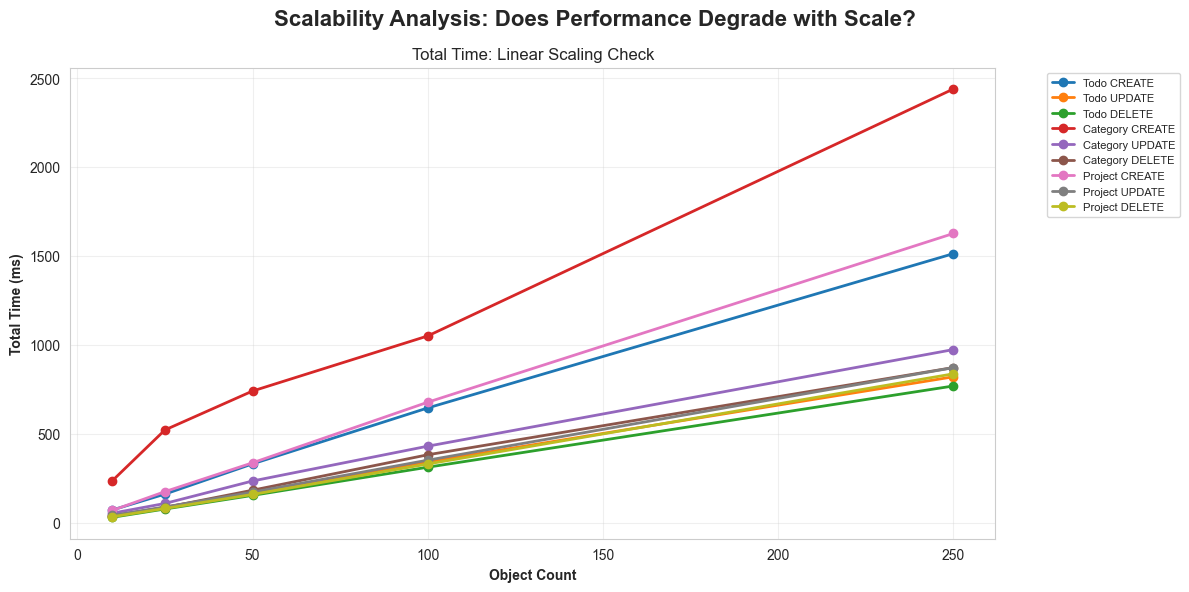

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('Scalability Analysis: Does Performance Degrade with Scale?', fontsize=16, fontweight='bold')

# Total time (shows linear vs non-linear scaling)
for entity in entities:
    for op in operations:
        data = crud_ops[(crud_ops['Entity'] == entity) & (crud_ops['OperationType'] == op)]
        if len(data) > 0:
            ax.plot(data['ObjectCount'], data['TotalTimeMs'], 
                   marker='o', label=f'{entity} {op}', linewidth=2)

ax.set_xlabel('Object Count', fontweight='bold')
ax.set_ylabel('Total Time (ms)', fontweight='bold')
ax.set_title('Total Time: Linear Scaling Check')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / 'scalability_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Heatmap: Performance Overview

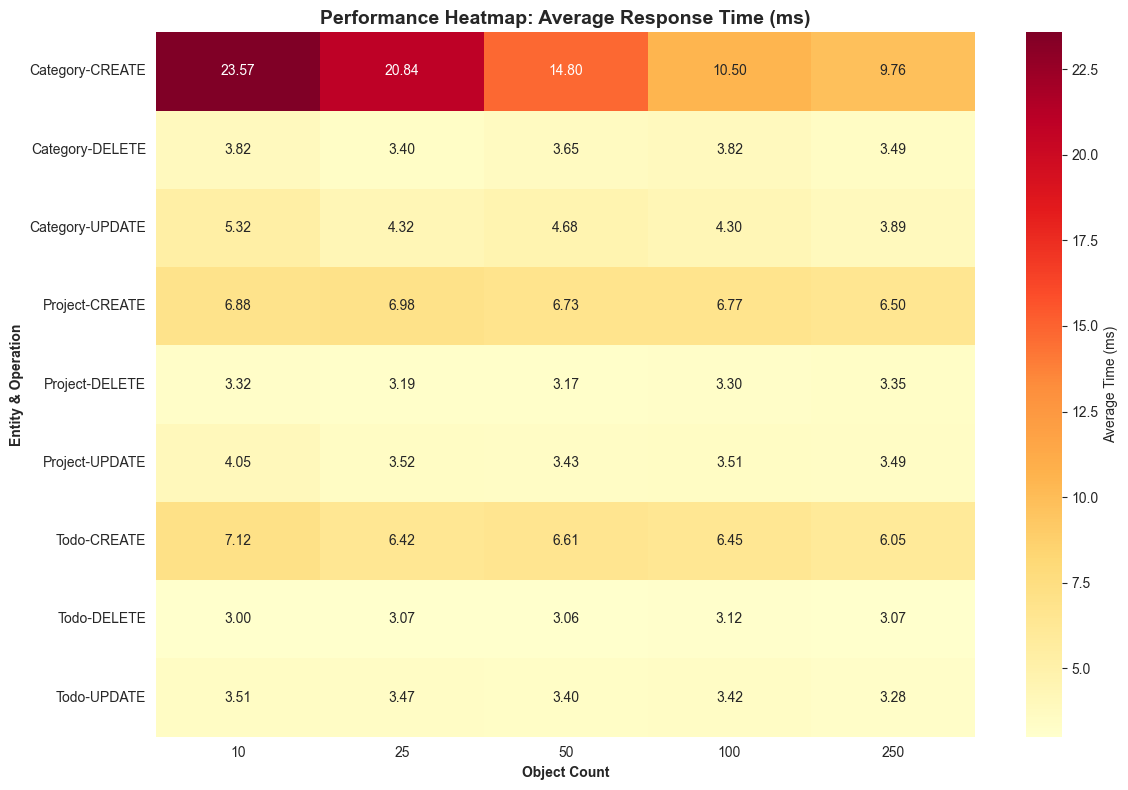

In [5]:
pivot_data = crud_ops.pivot_table(
    values='AverageTimeMs',
    index=['Entity', 'OperationType'],
    columns='ObjectCount',
    aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(pivot_data, annot=True, fmt='.2f', cmap='YlOrRd', 
            cbar_kws={'label': 'Average Time (ms)'}, ax=ax)
ax.set_title('Performance Heatmap: Average Response Time (ms)', fontsize=14, fontweight='bold')
ax.set_xlabel('Object Count', fontweight='bold')
ax.set_ylabel('Entity & Operation', fontweight='bold')

plt.tight_layout()
plt.savefig(output_dir / 'performance_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()